In [100]:
import numpy as np
import PACKAGE_LAB

import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors
from importlib import reload
PACKAGE_LAB = reload(PACKAGE_LAB)

from PACKAGE_LAB import LL_RT
from package_DBR import SelectPath_RT, Delay_RT, Process




## Lead lag real time

In [102]:
help(LL_RT)

Help on function LL_RT in module PACKAGE_LAB:

LL_RT(MV, Kp, TLead, TLag, Ts, PV, PVInit=0, method='EBD')



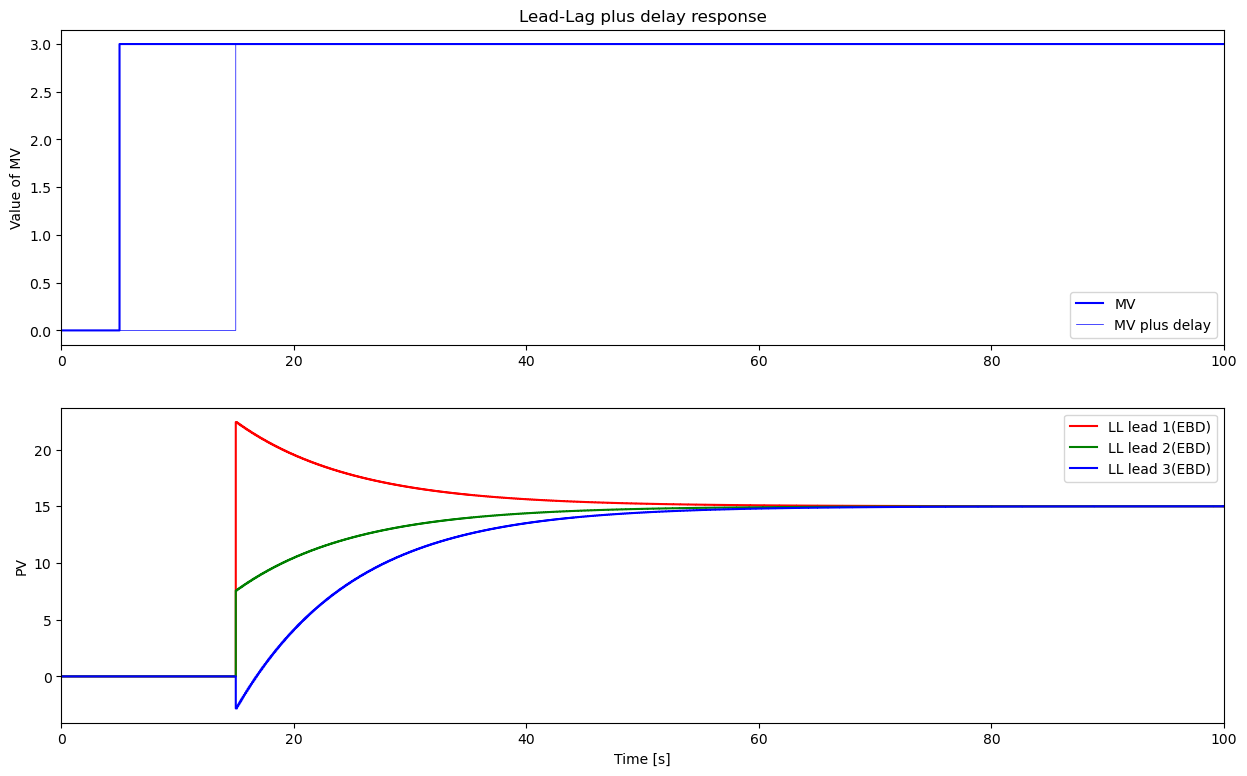

In [103]:
TSim = 100
Ts = 0.1
N = int(TSim / Ts) + 1
theta = 5
Kp = 5

Tlead_1 = 15
Tlead_2 = 5
Tlead_3 = -2
Tlag = 10
theta = 10

global MVFF
MVPath = {0: 0, 5:3, TSim: 3}
t = []
MV = []
PV = []
MVDelay = []
PV_EBD_1 = []
PV_EBD_LEAD1 = []
PV_EBD_LEAD2 = []
PV_EBD_LEAD3 = []

for i in range(0, N):
    t.append(i * Ts)
    SelectPath_RT(MVPath, t, MV)
    Delay_RT(MV, theta, Ts, MVDelay)
    LL_RT(MVDelay, Kp, Tlead_1, Tlag, Ts, PV_EBD_LEAD1)
    LL_RT(MVDelay, Kp, Tlead_2, Tlag, Ts, PV_EBD_LEAD2)
    LL_RT(MVDelay, Kp, Tlead_3, Tlag, Ts, PV_EBD_LEAD3)

plt.figure(figsize=(15, 9))

plt.subplot(2, 1, 1)
plt.step(t, MV, 'b-', label='MV', where='post')
plt.step(t, MVDelay, 'b-', linewidth=0.5, label='MV plus delay', where='post')
plt.ylabel('Value of MV')
plt.title('Lead-Lag plus delay response')
plt.legend(loc='best')
plt.xlim([0, TSim])

plt.subplot(2, 1, 2)
plt.step(t, PV_EBD_LEAD1, 'r-', label='LL lead 1(EBD)', where='post')
plt.step(t, PV_EBD_LEAD2, 'g-', label='LL lead 2(EBD)', where='post')
plt.step(t, PV_EBD_LEAD3, 'b-', label='LL lead 3(EBD)', where='post')

plt.ylabel('PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')
plt.xlim([0, TSim])

plt.show()